## 1. Marketplace Exploration  

Goal:  

    1. Build intuition about the current marketplace through descriptive analytics  
    2. Build visualization to support our intuition  
       a. Sellers per ASIN  
       b. Price Dispersion  
       c. Buy Box Dynamics  
          - Buy Box Win Rate by Price Rank
          - Buy Box vs. Fulfillment Type  
          - Buy Box vs. Shipping Speed  
       d. Demand Allocation  
          1. Units Sold vs. Buy Box
          2. Units Sold vs. Price Rank 
       e. Profit vs. Price  

In [5]:
import pandas as pd 
import numpy as np  
from pathlib import Path
import matplotlib.pyplot as plt 
import seaborn as sns 
import os 


#PROJECT_ROOT = Path.cwd().resolve()
#print("Project root:", PROJECT_ROOT)

In [2]:
# load data into dataframe

df = pd.read_csv("data/synthetic/marketplace_panel.csv")

df.head()

,day,asin,seller_id,seller_rating,fulfillment_type,shipping_days,product_cost,target_price,base_demand,price,...,price_gap_to_lowest,buy_box_probability,buy_box_winner,market_demand_units,units_sold,revenue,amazon_referral_fee,fulfillment_cost,contribution_profit_per_unit,contribution_profit
0,1,A0001,S032,88.5,FBA,2,82.06,120.02,40,113.24,...,0.00,0.6786,0,49,3,339.72,16.99,5.90,8.29,24.87
1,1,A0001,S028,92.1,FBM,5,82.06,120.02,40,113.80,...,0.56,0.0874,1,49,39,4438.20,17.07,6.25,8.42,328.38
2,1,A0001,S018,86.2,FBM,3,82.06,120.02,40,115.80,...,2.56,0.0348,0,49,2,231.60,17.37,5.55,10.82,21.64
3,1,A0001,S021,91.8,FBA,2,82.06,120.02,40,115.87,...,2.63,0.1474,0,49,4,463.48,17.38,5.90,10.53,42.12
4,1,A0001,S012,93.1,FBA,2,82.06,120.02,40,118.65,...,5.41,0.0350,0,49,0,0.00,17.80,5.90,12.89,0.00


## 2.0 Plots  

## 2.10 Marketplace Structure

### 2.11 Sellers per ASIN

In [ ]:

sellers_per_asin = df.groupby('asin')['seller_id'].nunique()

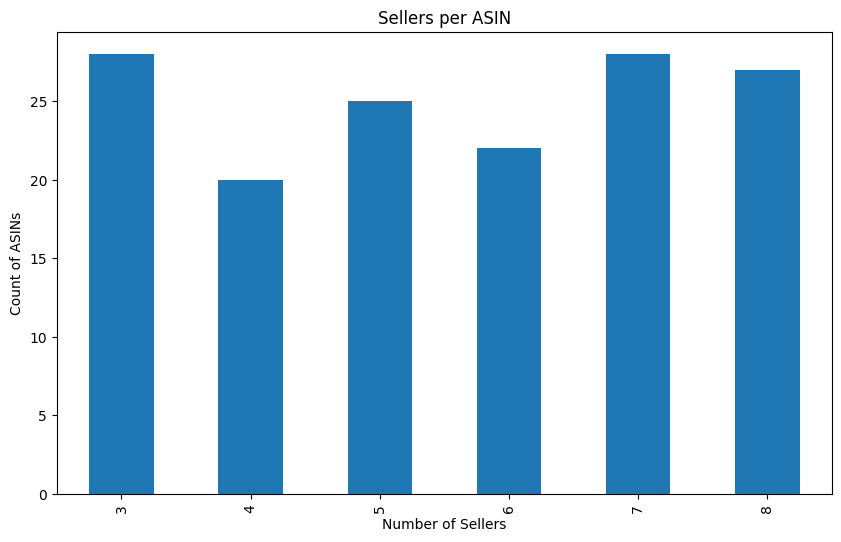

In [12]:
seller_dist = sellers_per_asin.value_counts().sort_index()

plt.figure(figsize=(10, 6))
seller_dist.plot(kind="bar")
plt.title("Sellers per ASIN")
plt.xlabel("Number of Sellers")
plt.ylabel("Count of ASINs")
plt.show()

### 2.12 Sellers per ASIN Insight  

    - All ASINs have multiple sellers, at least three, indicating competitiveness in the marketplace

### 2.20 Price Dispersion

    - Plot Coefficient of Variation (CV) to understand price competitiveness within an ASIN
    - Only calculation dispersion when there are multiple sellers

In [24]:
price_dispersion = (
    df.groupby(['day', 'asin'])
    .agg(
        price_std=('price', 'std'),
        seller_count=('seller_id', 'nunique')
    )
    .reset_index()
)

price_dispersion['cv'] = price_dispersion['price_std'] / df['price'].mean()

price_dispersion = (
    df.groupby(['day', 'asin'])
    .agg(
        price_std=('price', 'std'),
        price_mean=('price', 'mean'),
        seller_count=('seller_id', 'nunique')
    )
    .reset_index()
)

price_dispersion = price_dispersion[price_dispersion['seller_count'] > 1]

price_dispersion['cv'] = price_dispersion['price_std'] / price_dispersion['price_mean']

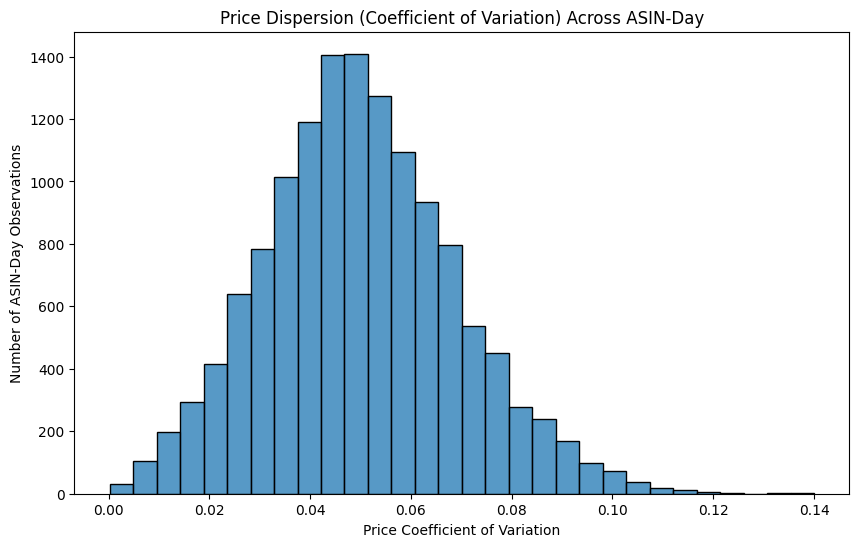

In [28]:
plt.figure(figsize=(10,6))
sns.histplot(data=price_dispersion, x='cv', bins=30)
plt.title("Price Dispersion (Coefficient of Variation) Across ASIN-Day")
plt.xlabel("Price Coefficient of Variation")
plt.ylabel("Number of ASIN-Day Observations")
plt.show()

### 2.21 Price Dispersion Insight  

    - The above plot shows how spread out prices are relative to the typical price  
    - This highlights how competitive pricing is within an ASIN with multiple sellers  

    - Bell shaped curve with slight right tail  
      - Center is around 0.04 to 0.06, meaning most ASIN-day combinations have a moderate price dispersion (about 4% to 6%.)  
      - In other words, sellers on the same ASIN are typically priced with 5% of each other.  
      - Right tail (.12 - .14) may suggest less competition or other factors may influence the large price difference such as seller ratings, inventory, or shipping speed.


|CV|Interpretation|
|-|-|
|~0|Prices are almost identical|
|0.05 - 0.15| Tight Pricing/Competitive|  

Low CV -> price likely determines Buy Box  
High CV -> other factors (seller rating, inventory, etc.) are more important in winning the Buy Box


### 2.30 Buy Box Dynamics

### 2.31 Buy Box Win Rate by Price Rank

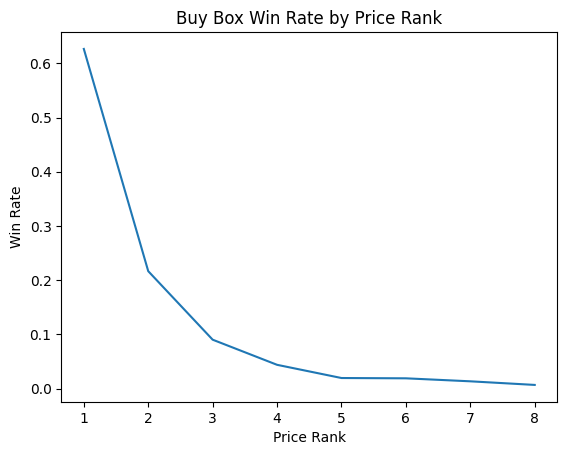

In [30]:
buybox_by_rank = (
    df.groupby("price_rank")["buy_box_winner"]
    .mean()
    .reset_index()
)

sns.lineplot(data=buybox_by_rank, x="price_rank", y="buy_box_winner")
plt.title("Buy Box Win Rate by Price Rank")
plt.ylabel("Win Rate")
plt.xlabel("Price Rank")
plt.show()

### 2.32 Buy Box Win Rate by Price Rank Insights  

    1. Highlights lower priced ASINs have a larger Buy Box Win Rate with having the lowest price (Price Rank = 1), winning the Buy Box ~60% of the time.  

    2. Where the Seller does not have the lowest price yet wins the Buy Box suggest other factors besides price influence the Buy Box Winner (i.e., seller rating, inventory, delivery speed, etc.)

### 2.40 Buy Box vs. Fulfillment Type  

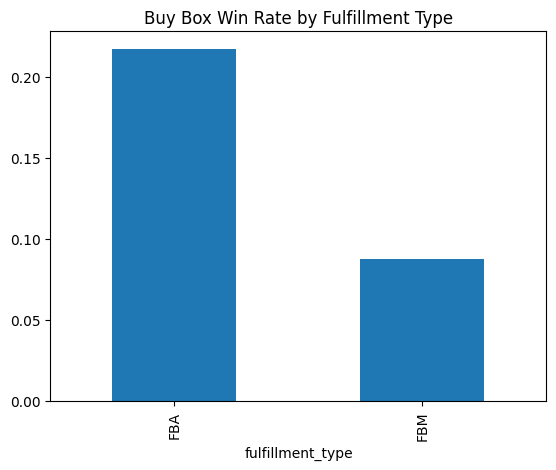

In [32]:
buybox_fba = (
    df.groupby('fulfillment_type')['buy_box_winner']
    .mean()
)

buybox_fba.plot(kind='bar')
plt.title("Buy Box Win Rate by Fulfillment Type")
plt.show()

### Buy Box Win Rate vs. Fulfillment Type  

    1. Fulfilled by Amazon (FBA) has a much higher average Buy Box Win Rate (~20%) vs. Fulfillment by Manufacturer (FBM) average Buy Box Rate (~9%)  

    2. This is expected as FBA may have consistent inventory over sellers  

### 2.50 Buy Box Win Rate vs. Shipping Speed  

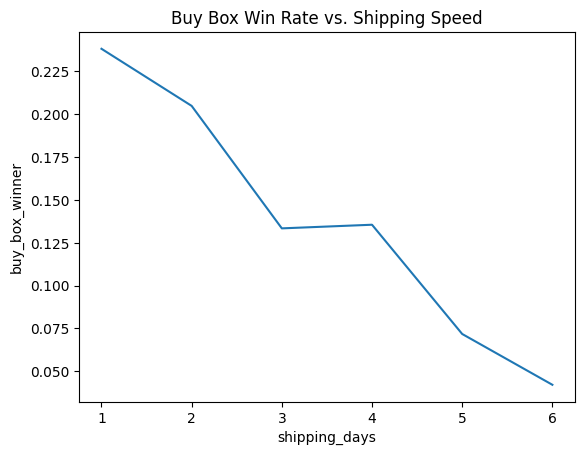

In [33]:
buybox_shipping = (
    df.groupby('shipping_days')['buy_box_winner']
    .mean()
    .reset_index()
)

sns.lineplot(data=buybox_shipping, x='shipping_days', y='buy_box_winner')
plt.title("Buy Box Win Rate vs. Shipping Speed")
plt.show()

### Buy Box Win Rate vs. Shipping Speed  

    1. Faster shipping (1 to 2 shipping days) have a much higher Buy Box Win Rate  

    2. This supports Amazon's philosophy of faster delivery increases customer satisfaction  

    3. Note: Intuitively, there may be multicolinearity with is_fba as fba sellers will have faster delivery.

### Demand Allocation  

### Units Sold vs. Buy Box Winner

In [34]:
df.groupby('buy_box_winner')['units_sold'].mean()

buy_box_winner
0     1.051749
1    22.530519
Name: units_sold, dtype: float64

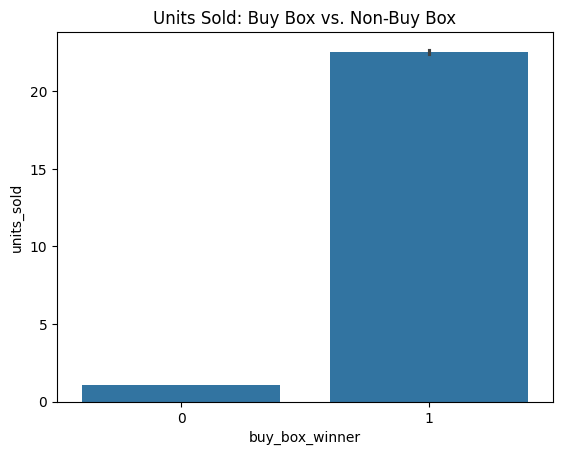

In [35]:
sns.barplot(data=df, x='buy_box_winner', y='units_sold')
plt.title('Units Sold: Buy Box vs. Non-Buy Box')
plt.show()

### Units Sold vs. Buy Box  

    1. On average, the buy box winner sells 22 units?  

### Units Sold vs. Price Rank

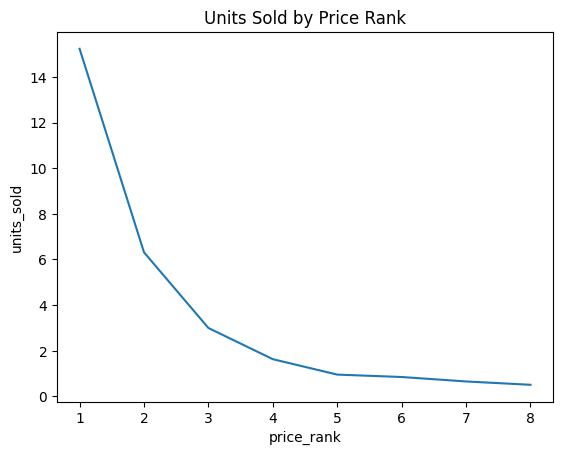

In [36]:
units_by_rank = (
    df.groupby('price_rank')['units_sold']
    .mean()
    .reset_index()
)

sns.lineplot(data=units_by_rank, x="price_rank", y='units_sold')
plt.title('Units Sold by Price Rank')
plt.show()

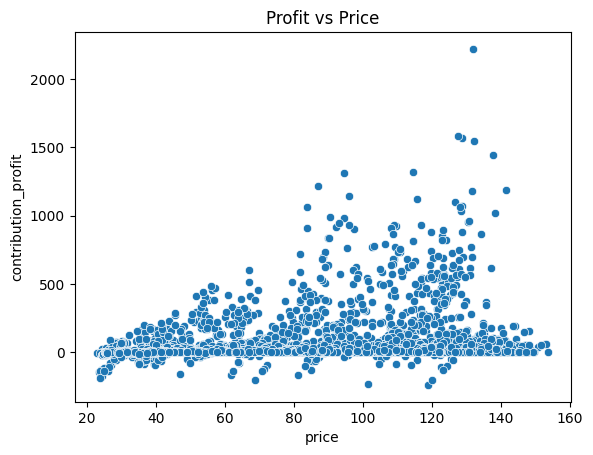

In [31]:
sns.scatterplot(data=df.sample(5000), x="price", y="contribution_profit")
plt.title("Profit vs Price")
plt.show()